# 1. Loading the Cleaned Train Dataset

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Load cleaned dataset
df_train = pd.read_csv("data\data_clean.csv")
df_train.head()


<>:8: SyntaxWarning: invalid escape sequence '\d'
<>:8: SyntaxWarning: invalid escape sequence '\d'
C:\Users\abina\AppData\Local\Temp\ipykernel_18792\2100922741.py:8: SyntaxWarning: invalid escape sequence '\d'
  df_train = pd.read_csv("data\data_clean.csv")


,customer_id,age,gender,country,tenure_months,monthly_spend,num_transactions,last_login_days,support_tickets,payment_method,is_active,total_spend,avg_transaction_value,target_churn,target_revenue,target_fraud,suspicion_score
0,1502,59,Male,Germany,2,185.360890,52,18,5,PayPal,0,370.721781,6.994751,1,382.034265,0,0.0
1,2587,25,Female,US,54,108.879222,35,17,7,Card,1,5879.477977,163.318833,0,217.996705,1,0.0
2,2654,38,Female,Germany,48,221.927474,5,2,5,PayPal,1,10652.518741,1775.419790,0,208.955628,0,0.0
3,1056,48,Male,US,26,275.346433,14,26,5,Card,1,7159.007247,477.267150,0,248.913546,0,0.0
4,706,53,Male,UK,15,444.016783,95,20,0,Card,1,6660.251746,69.377622,0,768.714022,0,0.3


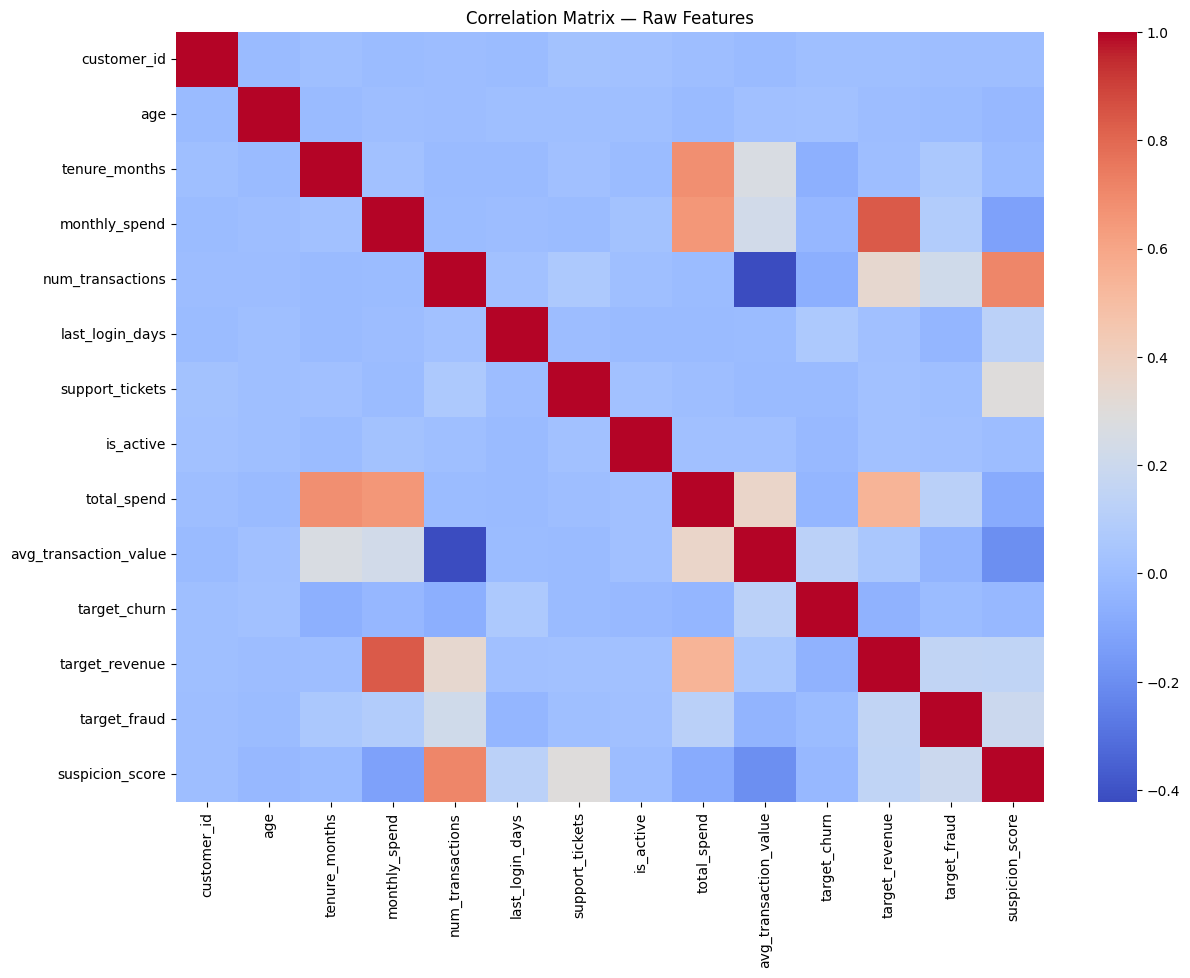

In [2]:
#Raw Correlation Matrix (Before Engineering)

df_train_raw = df_train.copy()

plt.figure(figsize=(14,10))
sns.heatmap(df_train_raw.select_dtypes(include=np.number).corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Matrix — Raw Features")
plt.show()



## 1.2. Core Behavioural Features (Transaction Intensity)

In [3]:
# Transaction intensity (raw)
#df_train['txn_intensity'] = df_train['num_transactions']

# Burstiness: many transactions in few login days
df_train['txn_burstiness'] = df_train['num_transactions'] / (df_train['last_login_days'] + 1)

# Login frequency
df_train['login_frequency'] = 1 / (df_train['last_login_days'] + 1)


Analysis has shown that num_transactions is the strongest fraud signal. Hence, these engineered features capture behavioural intensity, which is the heart of fraud detection.

## 1.3. Velocity and Ratio Features

In [4]:
# Spend velocity
df_train['spend_velocity'] = df_train['monthly_spend'] / df_train['num_transactions']

# Ratio of average to total spend
df_train['avg_vs_total_ratio'] = df_train['avg_transaction_value'] / (df_train['total_spend'] + 1)

Even though raw spend features are weak, ratios reveal patterns:

- Many small transactions
- High spend but spread across many transactions
- Inconsistent spending behaviour
- Fraudsters often behave differently in how they spend, not just how much.

Ratios expose these hidden patterns.

## 1.4. Atypicality Features (Z‑Scores by Group)

In [5]:
# Payment‑method z‑scores

df_train['z_num_txn_payment'] = df_train.groupby('payment_method')['num_transactions'].transform(
    lambda x: (x - x.mean()) / x.std()
)

# Country‑level z‑scores

df_train['z_num_txn_country'] = df_train.groupby('country')['num_transactions'].transform(
    lambda x: (x - x.mean()) / x.std()
)

df_train['z_monthly_spend_country'] = df_train.groupby('country')['monthly_spend'].transform(
    lambda x: (x - x.mean()) / x.std()
)


This is one of the most powerful fraud signals. Fraudsters often behave unusually compared to people like them. 
A customer making 100 transactions may be normal in the UK, but extremely abnormal in a low‑activity country.

Z‑scores measure:
“How weird is this customer compared to their peer group?”

This is a built‑in anomaly detector, which is perfect for fraud.

## 1.5. Keep the Validated Rule‑Based Feature

In [6]:
# suspicion_score already exists and is validated
df_train['suspicion_score'] = df_train['suspicion_score']

It has already been validated that the updated score:

- Has a stronger fraud gradient
- Separates fraud vs non‑fraud better

This is expert knowledge encoded into a number. The model benefits from this hybrid human + machine signal.

## 1.6. Minimal Encoding for Weak Categorical Features

In [7]:
# Gender (binary)
df_train['gender_binary'] = df_train['gender'].map({'Male': 1, 'Female': 0})

# Country (light one-hot)
country_dummies = pd.get_dummies(df_train['country'], prefix='country', drop_first=True)
df_train = pd.concat([df_train, country_dummies], axis=1)

# Payment method (light one-hot)
pm_dummies = pd.get_dummies(df_train['payment_method'], prefix='pm', drop_first=True)
df_train = pd.concat([df_train, pm_dummies], axis=1)


These features:

- Have around 17% fraud rate each
- Do not help directly
- But are needed for z‑scores and group structure

So we keep a lightweight encoded version and drop the raw columns. This avoids noise while preserving useful context.

## 1.7. Interaction Features (Only with num_transactions)

In [8]:
df_train['txn_x_spend'] = df_train['num_transactions'] * df_train['monthly_spend']
df_train['txn_x_login'] = df_train['num_transactions'] / (df_train['last_login_days'] + 1)

Interactions help the model understand combined behaviour.

Example:

- Behaviour 1 = High transactions + high spend
- Behaviour 2 =  High transactions + low spend

But since only num_transactions is strong, we only create interactions involving that feature. This avoids unnecessary noise.

## 1.8. Fit on Train for Apply Z‑Score Features to Test

In [9]:
pm_mean = df_train.groupby('payment_method')['num_transactions'].mean()
pm_std  = df_train.groupby('payment_method')['num_transactions'].std()

country_txn_mean = df_train.groupby('country')['num_transactions'].mean()
country_txn_std  = df_train.groupby('country')['num_transactions'].std()

country_spend_mean = df_train.groupby('country')['monthly_spend'].mean()
country_spend_std  = df_train.groupby('country')['monthly_spend'].std()


For Z-score feature, in train, this code was used:
    
    df.groupby('payment_method')['num_transactions'].transform(...)


This is not allowed for test, as it leaks test statistics. Instead, compute group means/stds on train. Group means/stds are computed on train and so that it can be applied to test

## 1.9. Drop Redundant or Low‑Value Columns 

In [10]:
cols_to_drop_train = [
    'customer_id',             # identifier
    'avg_transaction_value',   # weak signal
    'gender',                  # replaced by gender_binary
    'country',                 # encoded
    'payment_method',          # encoded
    'target_churn',            # target variable
    'target_revenue',          # target variable
]

df_train = df_train.drop(columns=cols_to_drop_train)



## 1.10. Save Train Engineering Dataset

In [11]:

# Move target_fraud to the end
cols = [col for col in df_train.columns if col != 'target_fraud'] + ['target_fraud']
df_train = df_train[cols]

df_train.to_csv("feature_engineering_datasets/train_engineered.csv", index=False)

Justification on droping the following columns:

| Column | Reason for Dropping |
| --- | --- |
| **customer_id** | Identifier, no predictive value |
| **gender** | Replaced by ``gender_binary`` |
| **country** | Replaced by one‑hot encoded ``country_*`` |
| **payment_method** | Replaced by one‑hot encoded ``pm_*`` |
| **avg_transaction_value** | Redundant, weak signal, replaced by engineered features |
| **target_churn** | Target variable → leakage |
| **target_revenue** | Target variable → leakage |

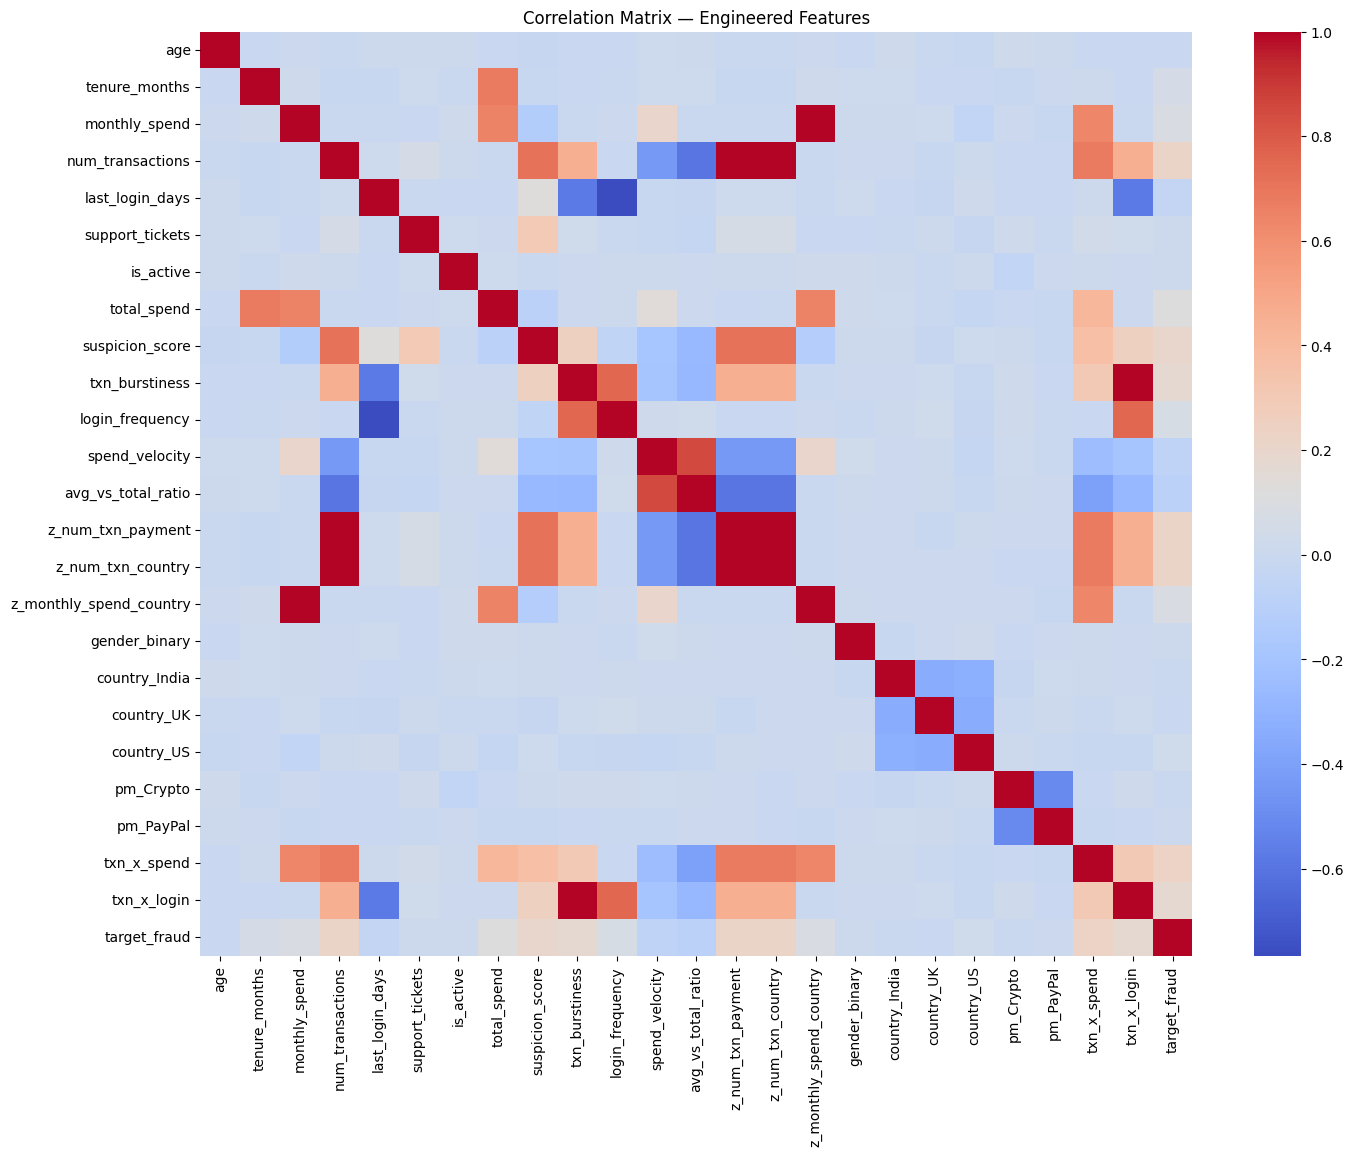

In [12]:
# Engineered Feature Correlation Matrix

plt.figure(figsize=(16,12))
sns.heatmap(df_train.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Matrix — Engineered Features")
plt.show()


This reveals:

- engineered features cluster around behavioural intensity
- z‑scores correlate with each other
- interactions correlate with num_transactions
- PCA is justified because multicollinearity increases

In [13]:
# Feature vs Target Correlation Ranking

df_train.corr()['target_fraud'].sort_values(ascending=False)


target_fraud               1.000000
txn_x_spend                0.233938
z_num_txn_payment          0.218744
num_transactions           0.218724
z_num_txn_country          0.218482
suspicion_score            0.196691
txn_burstiness             0.178526
txn_x_login                0.178526
total_spend                0.120784
z_monthly_spend_country    0.088087
monthly_spend              0.086591
login_frequency            0.069763
tenure_months              0.057183
country_US                 0.029530
is_active                  0.011406
support_tickets            0.009230
gender_binary              0.007658
pm_PayPal                  0.003954
pm_Crypto                 -0.001379
country_India             -0.004734
age                       -0.007900
country_UK                -0.010713
last_login_days           -0.038192
spend_velocity            -0.063735
avg_vs_total_ratio        -0.087637
Name: target_fraud, dtype: float64

This gives you a ranked list of:

- strongest predictors
- weakest predictors
- whether engineered features improved signal

## 1.11. Save Scale Train Engineering Dataset

In [14]:


feature_cols = [
    # Core numeric
    'age',
    'tenure_months',
    'monthly_spend',
    'num_transactions',
    'last_login_days',
    'support_tickets',
    'is_active',
    'total_spend',
    'suspicion_score',

    # Encoded categorical
    'gender_binary',

    # Behavioural engineered features
    #'txn_intensity',
    'txn_burstiness',
    'login_frequency',

    # Ratio features
    'spend_velocity',
    'avg_vs_total_ratio',

    # Z-score features
    'z_num_txn_payment',
    'z_num_txn_country',
    'z_monthly_spend_country',

    # Interaction features
    'txn_x_spend',
    'txn_x_login'
]

# Add one-hot encoded columns
one_hot_cols = [col for col in df_train.columns if col.startswith('country_') or col.startswith('pm_')]
feature_cols += one_hot_cols


# Fit scaler on training data
scaler = StandardScaler()
scaler.fit(df_train[feature_cols])

# Transform train and test
train_scaled = scaler.transform(df_train[feature_cols])

train_scaled = pd.DataFrame(df_train, columns=feature_cols)
#train_scaled.to_csv("feature_engineering_datasets/train_scaled.csv", index=False)

# 2. Loading Cleaned Test Dataset

In [15]:


# Load cleaned dataset
df_test = pd.read_csv("data/test.csv")
df_test.head()

,customer_id,age,gender,country,tenure_months,monthly_spend,num_transactions,last_login_days,support_tickets,payment_method,is_active,total_spend,avg_transaction_value,target_churn,target_revenue,target_fraud
0,4,32,Male,India,6,493.432084,62,1,0,Card,1,2960.592506,46.993532,0,439.266022,0
1,5,60,Male,US,26,62.512723,98,29,2,Card,1,1625.330809,16.417483,0,239.534131,0
2,6,25,Female,Germany,11,159.810811,31,24,3,Card,0,1757.918918,54.934966,0,238.382316,0
3,10,40,Female,UK,52,329.295536,63,19,1,Crypto,1,17123.367884,267.552623,0,565.054008,0
4,17,20,Female,US,12,356.147050,18,17,0,PayPal,1,4273.764598,224.934979,0,362.108839,0


## 2.1. Apply Row‑Level Features to Test (Safe)

In [16]:
def add_row_level_features(df):
    #df['txn_intensity'] = df['num_transactions']
    df['txn_burstiness'] = df['num_transactions'] / (df['last_login_days'] + 1)
    df['login_frequency'] = 1 / (df['last_login_days'] + 1)
    df['spend_velocity'] = df['monthly_spend'] / (df['num_transactions'] + 1)
    df['avg_vs_total_ratio'] = df['avg_transaction_value'] / (df['total_spend'] + 1)
    df['txn_x_spend'] = df['num_transactions'] * df['monthly_spend']
    df['txn_x_login'] = df['num_transactions'] / (df['last_login_days'] + 1)
    return df

df_test = add_row_level_features(df_test)

## 2.3. Apply Z‑Score Features (Fit on Train to Apply to Test)

In [17]:
df_test['z_num_txn_payment'] = (df_test['num_transactions'] - df_test['payment_method'].map(pm_mean)) / df_test['payment_method'].map(pm_std)

df_test['z_num_txn_country'] = (df_test['num_transactions'] - df_test['country'].map(country_txn_mean)) / df_test['country'].map(country_txn_std)

df_test['z_monthly_spend_country'] = (df_test['monthly_spend'] - df_test['country'].map(country_spend_mean)) / df_test['country'].map(country_spend_std)


This is the correct leakage‑safe method.

## 2.2. Apply Encoding to Test (Fit on Train to Transform Test)

In [18]:
df_test = pd.get_dummies(
    df_test,
    columns=['country', 'payment_method'],
    prefix=['country', 'pm'],
    drop_first=True
)

# Align with train
df_test = df_test.reindex(columns=df_train.columns, fill_value=0)

## 2.4. Drop the Same Columns in Test as Train

In [19]:
df_test = df_test.reindex(columns=df_train.columns, fill_value=0)

cols_to_drop_test = [
    'customer_id',             # identifier
    'avg_transaction_value',   # weak signal
    'gender',                  # replaced by gender_binary
    'country',                 # encoded
    'payment_method',          # encoded
    'target_churn',            # target variable
    'target_revenue',          # target variable
    'target_fraud'             # target variable (not in test)
]

df_test = df_test.drop(columns=cols_to_drop_test, errors='ignore')

## 2.5. Save Test Engineering Dataset

In [20]:
df_test.to_csv( "feature_engineering_datasets/test_engineered.csv", index=False)

## 2.6. Scale Test Using Train’s Scaler (Fit on Train → Transform Test)

In [21]:
scaler = StandardScaler()

train_scaled = scaler.fit_transform(df_train[feature_cols])

test_scaled = scaler.transform(df_test[feature_cols])



## 2.7. Save Scaleed Test Engineering Dataset

In [22]:
train_scaled = pd.DataFrame(train_scaled, columns=feature_cols )
train_scaled['target_fraud'] = df_train['target_fraud']
train_scaled.to_csv("feature_engineering_datasets/train_scaled.csv", index=False)

In [23]:
test_scaled = pd.DataFrame(test_scaled, columns=feature_cols)
test_scaled.to_csv("feature_engineering_datasets/test_scaled.csv", index=False)

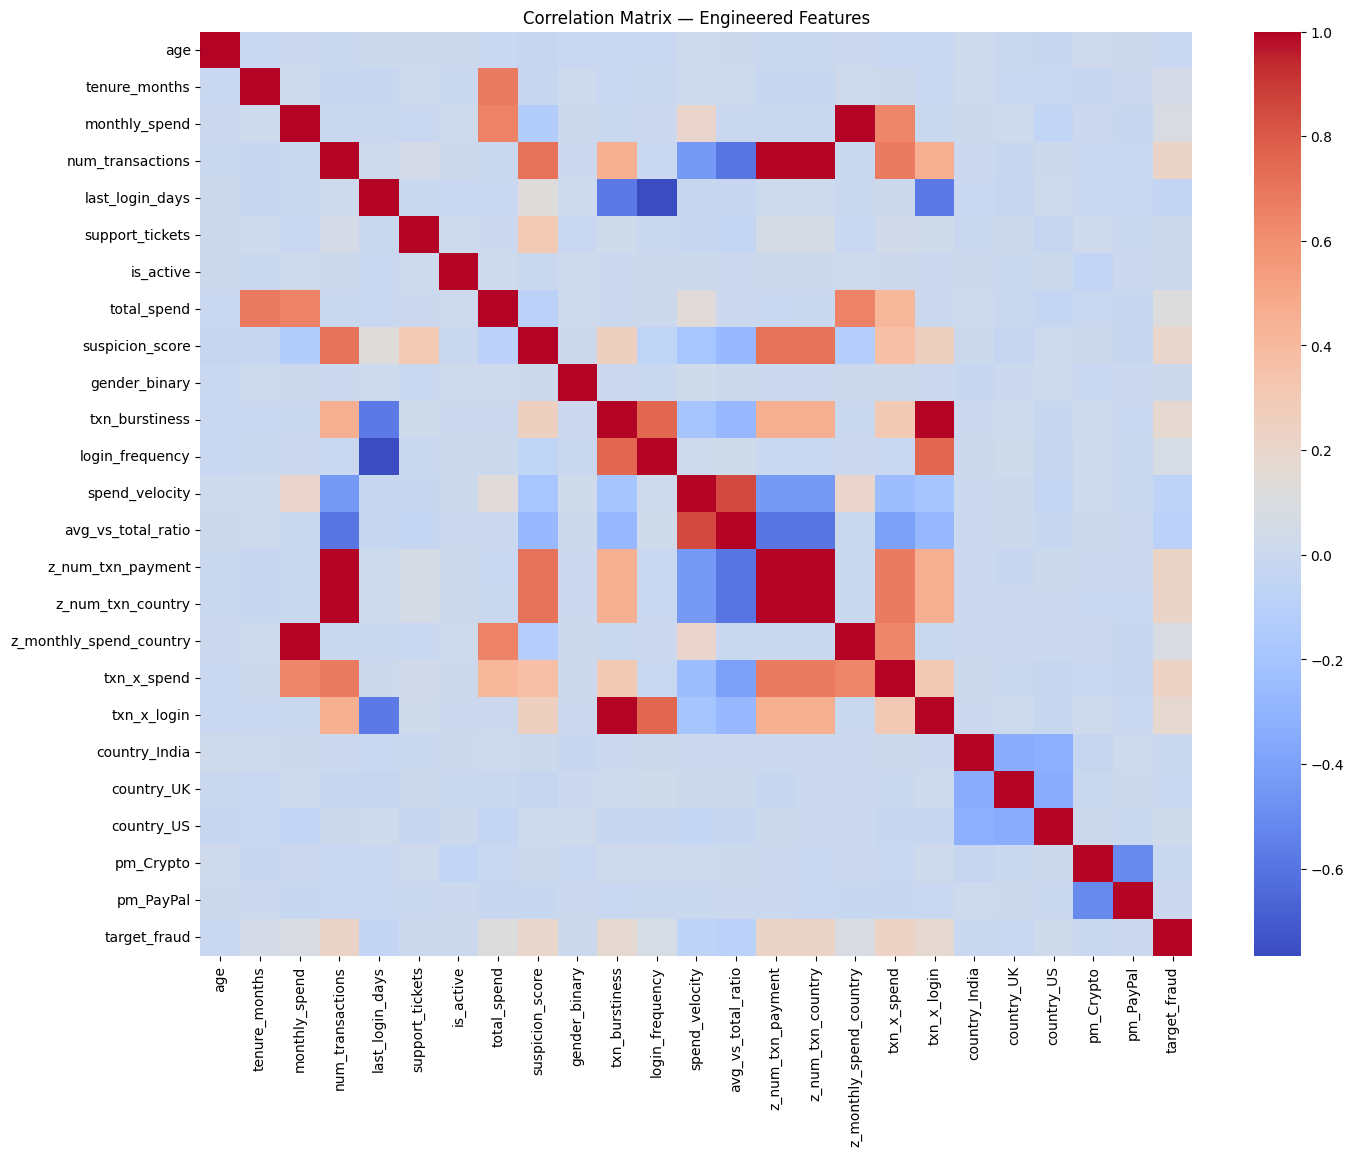

In [24]:
plt.figure(figsize=(16,12))
sns.heatmap(train_scaled.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Matrix — Engineered Features")
plt.show()


## 3.8. Save the scaler and PCA objects (critical for deployment)

In [25]:
import joblib
joblib.dump(scaler, "models/scaler.pkl")


['models/scaler.pkl']